In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

loss, accuracy = model.evaluate(x_test, y_test)
print("Accuracy:", accuracy)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.8972 - loss: 0.3349 - val_accuracy: 0.9615 - val_loss: 0.1217
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9512 - loss: 0.1645 - val_accuracy: 0.9713 - val_loss: 0.0960
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9606 - loss: 0.1319 - val_accuracy: 0.9773 - val_loss: 0.0758
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9669 - loss: 0.1090 - val_accuracy: 0.9782 - val_loss: 0.0757
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9702 - loss: 0.0965 - val_accuracy: 0.9812 - val_loss: 0.0665
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9777 - loss: 0.0783
Accuracy: 0.9776999950408936


In [2]:
prediction = model.predict(x_test[:1])

print("Predicted Digit:", np.argmax(prediction))
print("Actual Digit:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Predicted Digit: 7
Actual Digit: 7


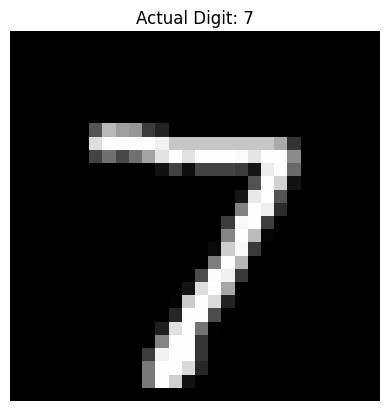

In [3]:
plt.imshow(x_test[0], cmap='gray')
plt.title(f"Actual Digit: {y_test[0]}")
plt.axis('off')
plt.show()

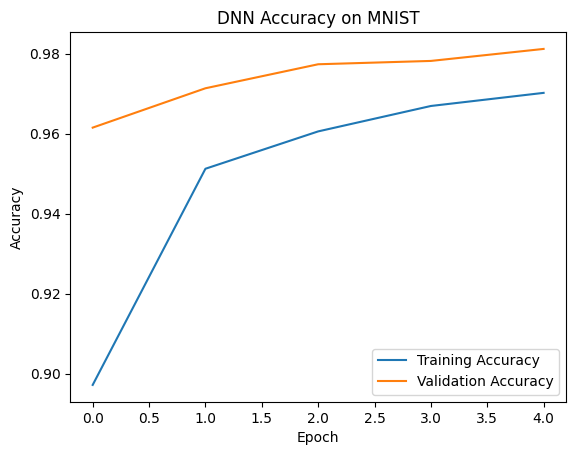

In [4]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('DNN Accuracy on MNIST')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [5]:
def step(x):
    return 1 if x >= 0 else 0

def AND_gate(x1, x2):
    w1 = 1
    w2 = 1
    b = -1.5

    net = w1*x1 + w2*x2 + b
    return step(net)

for x1 in [0,1]:
    for x2 in [0,1]:
        print(x1, x2, "->", AND_gate(x1,x2))

0 0 -> 0
0 1 -> 0
1 0 -> 0
1 1 -> 1


In [6]:
def OR_gate(x1, x2):
    w1 = 1
    w2 = 1
    b = -0.5

    net = w1*x1 + w2*x2 + b
    return step(net)

for x1 in [0,1]:
    for x2 in [0,1]:
        print(x1, x2, "->", OR_gate(x1,x2))

0 0 -> 0
0 1 -> 1
1 0 -> 1
1 1 -> 1


In [7]:
def NOT_gate(x):
    w = -1
    b = 0.5

    net = w*x + b
    return step(net)

print("NOT(0) =", NOT_gate(0))
print("NOT(1) =", NOT_gate(1))

NOT(0) = 1
NOT(1) = 0
